기본 라이브러리

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

폰트 설치

In [3]:
# 1) 나눔고딕 폰트 설치
!apt-get update -qq
!apt-get install -qq fonts-nanum

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 126281 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [4]:
# 2) matplotlib에 폰트 등록 & 설정
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# 나눔고딕 경로 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_manager.fontManager.addfont(font_path)

# 전체 폰트 설정
mpl.rc('font', family='NanumGothic')
# 음수 부호 깨짐 방지
mpl.rc('axes', unicode_minus=False)

각월별 6.채널정보 train 데이터 하나로 합치기

In [ ]:
# 기본 경로
base_path = '/content/drive/MyDrive/data/train/6.채널정보'

# 월별 파일 리스트 생성
months = ['201807', '201808', '201809', '201810', '201811', '201812']
file_list = [f'{base_path}/{month}_train_채널정보.parquet' for month in months]

# 파일을 읽어서 하나의 DataFrame으로 합치기
df_all = pd.concat([pd.read_parquet(file) for file in file_list], ignore_index=True)

# 결과 확인
print(df_all.shape)
df_all.head()

(2400000, 105)


,기준년월,ID,인입횟수_ARS_R6M,이용메뉴건수_ARS_R6M,인입일수_ARS_R6M,인입월수_ARS_R6M,인입후경과월_ARS,인입횟수_ARS_B0M,이용메뉴건수_ARS_B0M,인입일수_ARS_B0M,...,당사PAY_방문횟수_R6M,당사PAY_방문월수_R6M,당사멤버쉽_방문횟수_B0M,당사멤버쉽_방문횟수_R6M,당사멤버쉽_방문월수_R6M,OS구분코드,홈페이지_금융건수_R6M,홈페이지_선결제건수_R6M,홈페이지_금융건수_R3M,홈페이지_선결제건수_R3M
0,201807,TRAIN_000000,10회 이상,10회 이상,8,6,0,2,6,2,...,0,0,22,221,6,Android,0,0,0,0
1,201807,TRAIN_000001,1회 이상,1회 이상,0,0,0,0,0,0,...,0,0,0,0,0,None,0,0,0,0
2,201807,TRAIN_000002,1회 이상,1회 이상,1,1,0,2,5,1,...,0,0,0,0,0,Android,11,6,5,5
3,201807,TRAIN_000003,10회 이상,10회 이상,10,6,0,2,6,2,...,0,0,23,219,6,Android,0,0,0,0
4,201807,TRAIN_000004,1회 이상,1회 이상,0,0,0,0,0,0,...,0,0,0,0,0,Android,0,0,0,0


파일로 저장

In [ ]:
# 저장 경로
save_path = '/content/drive/MyDrive/파이널프로젝트 파일/EDA_merged_train.parquet'

# Parquet 형식으로 저장
df_all.to_parquet(save_path, index=False)

print(f"저장 완료: {save_path}")

저장 완료: /content/drive/MyDrive/파이널프로젝트 파일/EDA_merged_train.parquet


각월 별 1.회웑정보 train 데이터 하나로 합치기

In [ ]:
# 병합할 월 리스트
months = ['07', '08', '09', '10', '11', '12']

# 병합된 데이터를 담을 리스트
df_list = []

# 월별 파일 불러오기
for month in months:
    path = f'/content/drive/MyDrive/data/train/1.회원정보/2018{month}_train_회원정보.parquet'
    df_month = pd.read_parquet(path)
    df_list.append(df_month)

# 하나의 데이터프레임으로 병합
df_member_all = pd.concat(df_list, ignore_index=True)

# 결과 확인
print(f'병합된 데이터 shape: {df_member_all.shape}')
df_member_all.head()

병합된 데이터 shape: (2400000, 78)


,기준년월,ID,남녀구분코드,연령,Segment,회원여부_이용가능,회원여부_이용가능_CA,회원여부_이용가능_카드론,소지여부_신용,소지카드수_유효_신용,...,할인금액_제휴연회비_B0M,청구금액_기본연회비_B0M,청구금액_제휴연회비_B0M,상품관련면제카드수_B0M,임직원면제카드수_B0M,우수회원면제카드수_B0M,기타면제카드수_B0M,카드신청건수,Life_Stage,최종카드발급경과월
0,201807,TRAIN_000000,2,40대,D,1,1,0,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀성장(2),22
1,201807,TRAIN_000001,1,30대,E,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀성장(1),18
2,201807,TRAIN_000002,1,30대,C,1,1,0,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀출산기,20
3,201807,TRAIN_000003,2,40대,D,1,1,0,1,2,...,0,0,0,0개,0개,0개,0개,1,자녀성장(2),17
4,201807,TRAIN_000004,2,40대,E,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,1,자녀성장(1),15


Segment 칼럼만 가져와서 EDA_merged_train 에 합치기

In [ ]:
# 1. 기준년월과 ID, Segment만 선택
segment_info = df_member_all[['기준년월', 'ID', 'Segment']].copy()

# 2. df_all에 병합
df_all = df_all.merge(segment_info, on=['기준년월', 'ID'], how='left')

# 결과 확인
print(f'병합 후 df_all shape: {df_all.shape}')
print(df_all[['기준년월', 'ID', 'Segment']].head())

병합 후 df_all shape: (2400000, 106)
     기준년월            ID Segment
0  201807  TRAIN_000000       D
1  201807  TRAIN_000001       E
2  201807  TRAIN_000002       C
3  201807  TRAIN_000003       D
4  201807  TRAIN_000004       E


파일 저장

In [ ]:
# 저장 경로
save_path = '/content/drive/MyDrive/파이널프로젝트 파일/EDA_merged_ready_to_train.parquet'

# Parquet 파일로 저장
df_all.to_parquet(save_path, index=False)

print(f"저장 완료: {save_path}")

저장 완료: /content/drive/MyDrive/파이널프로젝트 파일/EDA_merged_ready_to_train.parquet


파일 블러오기

In [5]:
# 1. 데이터 로드 (Google Drive 마운트 후 경로 지정 필요)
file_path = '/content/drive/MyDrive/파이널프로젝트 파일/EDA_merged_ready_to_train.parquet'
df_all = pd.read_parquet(file_path)

칼럼 선정하기

In [ ]:

# 2. int64 타입 칼럼만 선택
int_cols = df_all.select_dtypes(include='int64')

# 3. 모든 값이 0인 칼럼 제외
non_all_zero_cols = [col for col in int_cols.columns if not (df_all[col] == 0).all()]

# 5. '일수' 또는 '월수'가 포함되지 않은 칼럼만 필터링
filtered_cols = [col for col in non_all_zero_cols if '일수' not in col and '월수' not in col]

# 5. 컬럼 인덱스(번호)와 이름 출력
filtered_info = [(df_all.columns.get_loc(col), col) for col in filtered_cols]

# 7. 결과 출력
print(f"\n필터링 후 컬럼 개수: {len(filtered_info)}개\n")
for idx, name in filtered_info:
    print(f"{idx}: {name}")


필터링 후 컬럼 개수: 48개

0: 기준년월
6: 인입후경과월_ARS
7: 인입횟수_ARS_B0M
8: 이용메뉴건수_ARS_B0M
13: 방문후경과월_PC_R6M
17: 방문후경과월_앱_R6M
18: 방문횟수_모바일웹_R6M
21: 방문후경과월_모바일웹_R6M
22: 방문횟수_PC_B0M
24: 방문횟수_앱_B0M
26: 방문횟수_모바일웹_B0M
28: 인입횟수_IB_R6M
32: 이용메뉴건수_IB_R6M
33: 인입후경과월_IB_R6M
34: 인입횟수_IB_B0M
36: 이용메뉴건수_IB_B0M
40: 인입불만후경과월_IB_R6M
43: 상담건수_B0M
44: IB문의건수_사용승인내역_B0M
46: IB문의건수_선결제_B0M
57: IB문의건수_카드발급_B0M
61: IB문의건수_CL_RV_B0M
62: IB문의건수_CS_B0M
67: 상담건수_R6M
68: IB문의건수_사용승인내역_R6M
69: IB문의건수_한도_R6M
70: IB문의건수_선결제_R6M
71: IB문의건수_결제_R6M
72: IB문의건수_할부_R6M
73: IB문의건수_정보변경_R6M
74: IB문의건수_결제일변경_R6M
76: IB문의건수_비밀번호_R6M
77: IB문의건수_SMS_R6M
79: IB문의건수_부대서비스_R6M
80: IB문의건수_포인트_R6M
81: IB문의건수_카드발급_R6M
82: IB문의건수_BL_R6M
83: IB문의건수_분실도난_R6M
84: IB문의건수_CA_R6M
85: IB문의건수_CL_RV_R6M
86: IB문의건수_CS_R6M
93: 불만제기후경과월_R12M
97: 당사멤버쉽_방문횟수_B0M
98: 당사멤버쉽_방문횟수_R6M
101: 홈페이지_금융건수_R6M
102: 홈페이지_선결제건수_R6M
103: 홈페이지_금융건수_R3M
104: 홈페이지_선결제건수_R3M


혼동 매트릭스를 그렸을 때, D,E의 오답이 많았으므로 각 칼럼별로 D,E 세그먼트 값이 아주 크거나 작은 특성을 가진 것을 확인해서 피처로 선정.

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


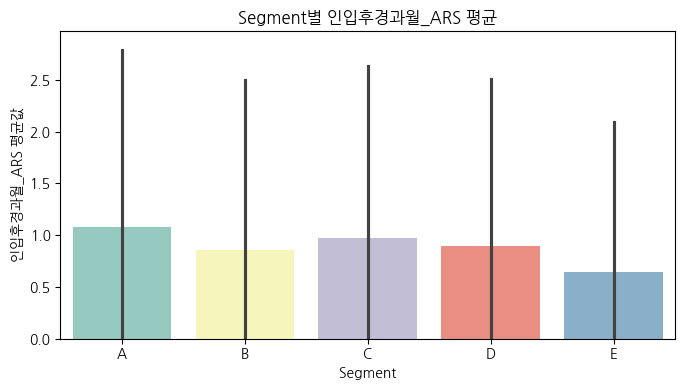

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


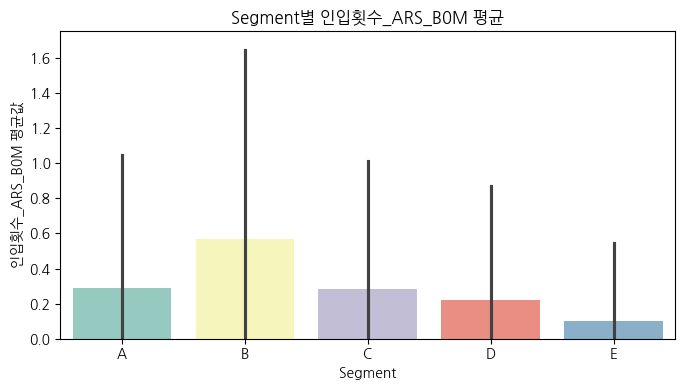

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


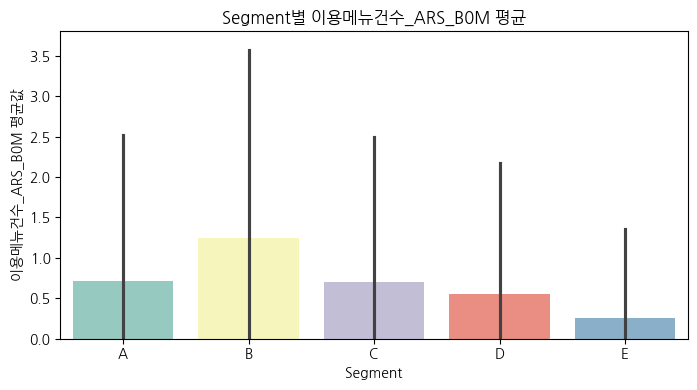

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


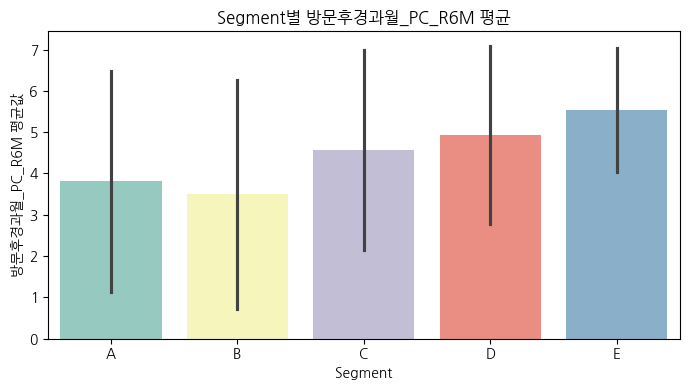

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


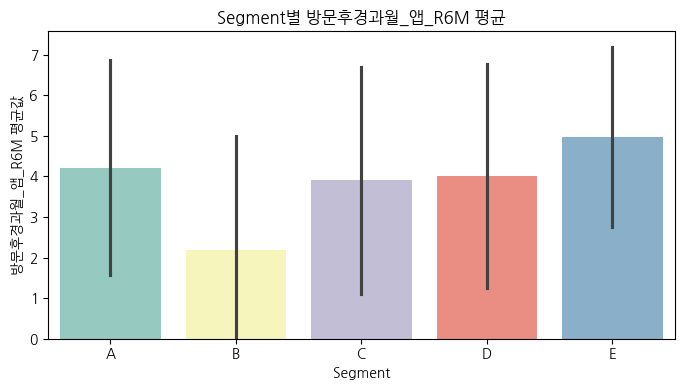

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


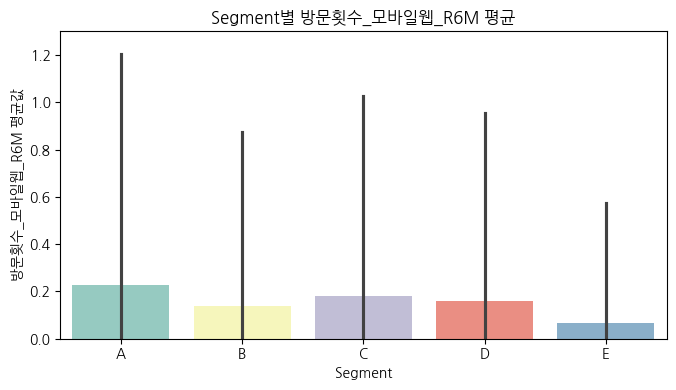

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


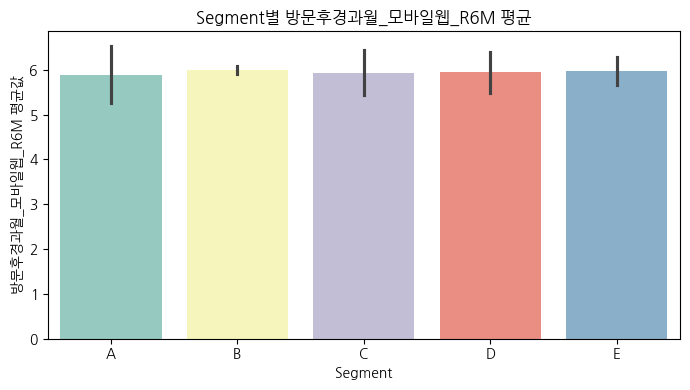

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


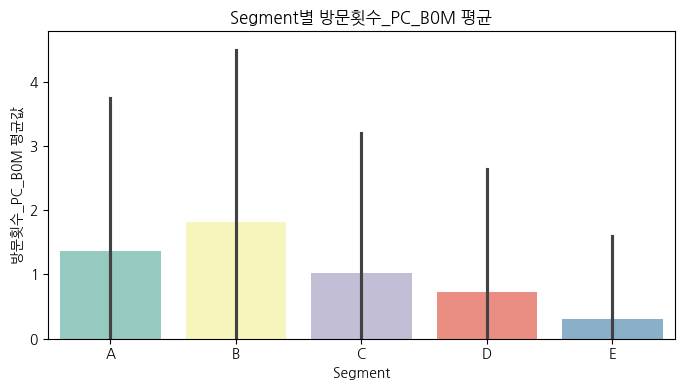

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


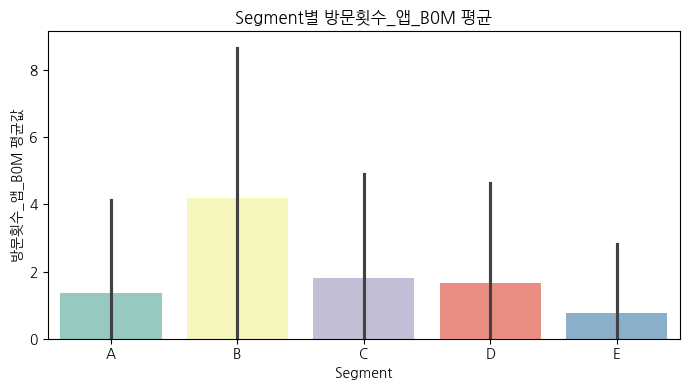

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


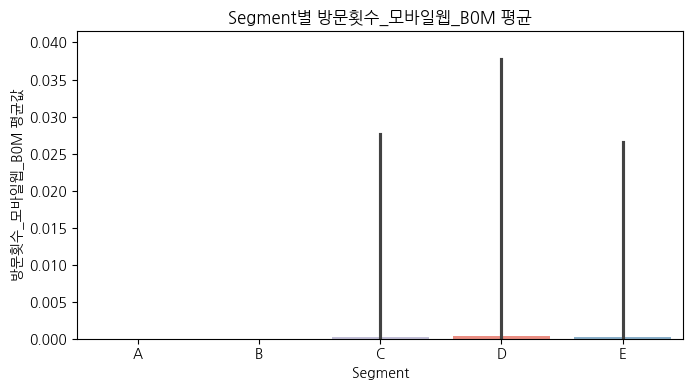

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


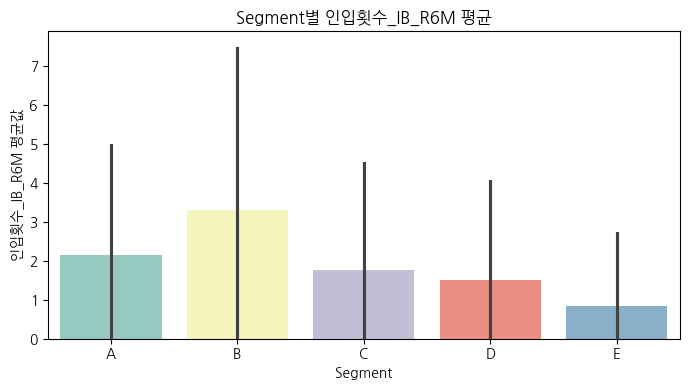

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


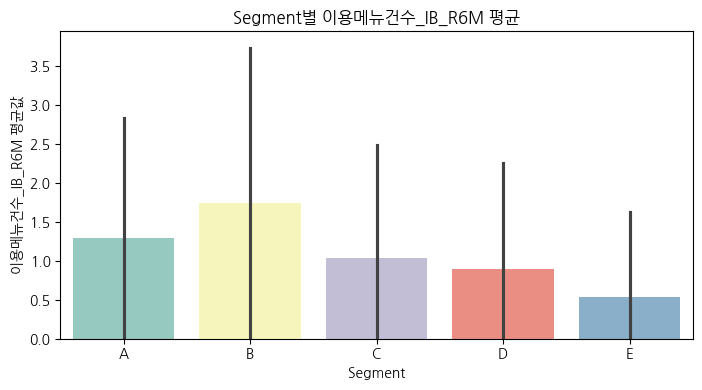

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


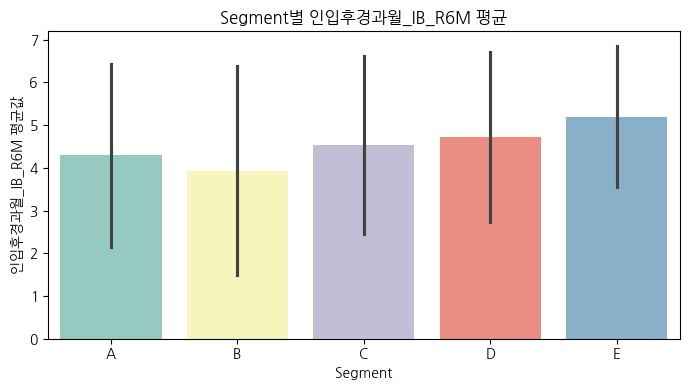

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


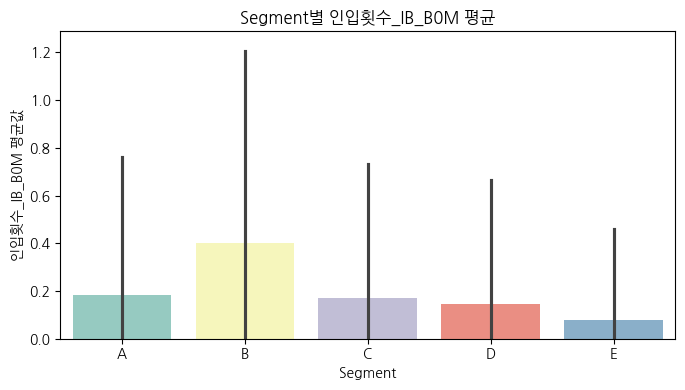

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


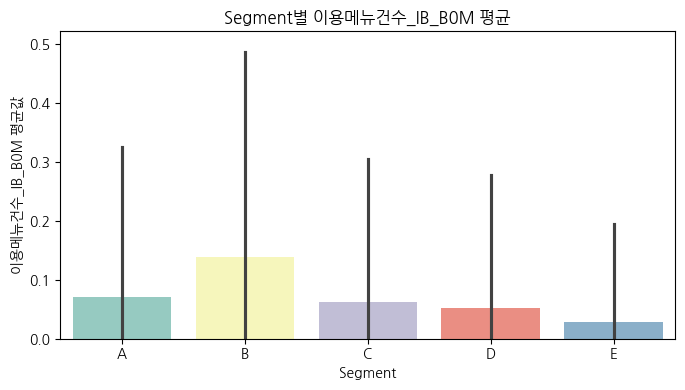

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


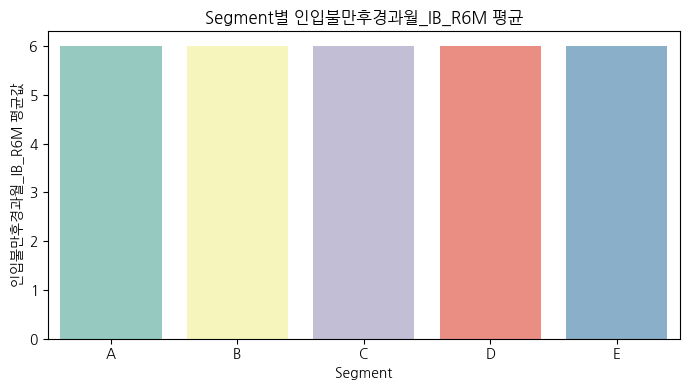

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


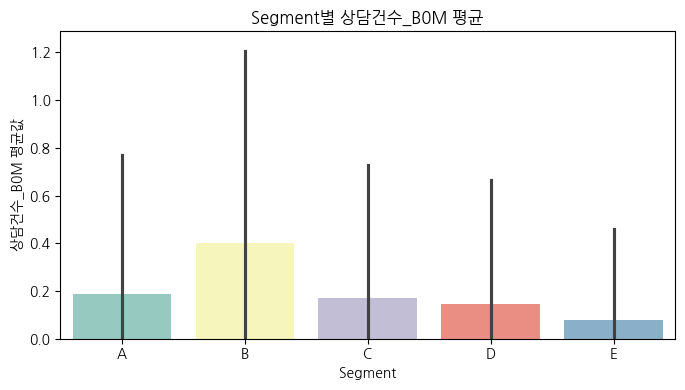

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


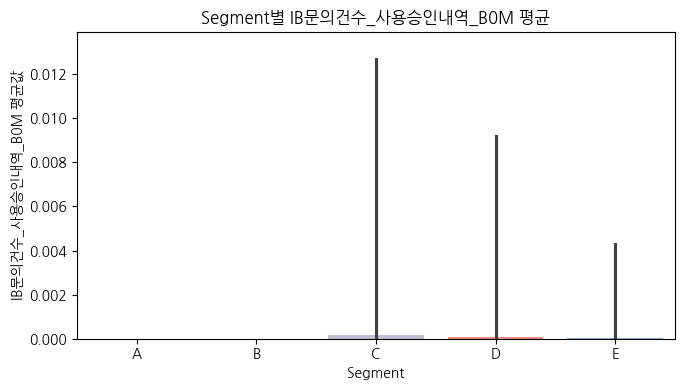

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


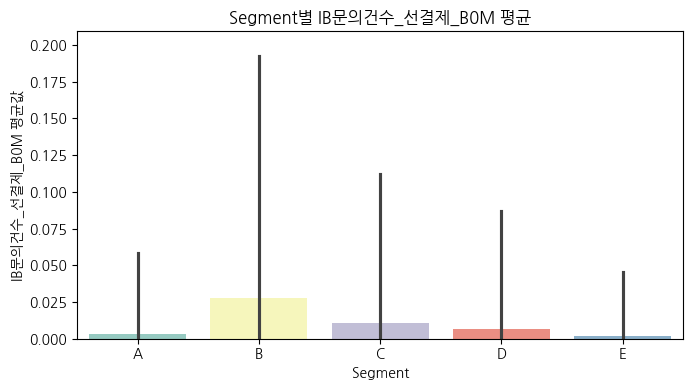

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


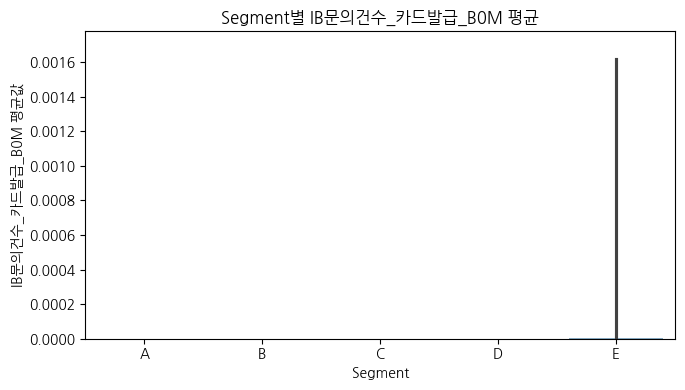

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


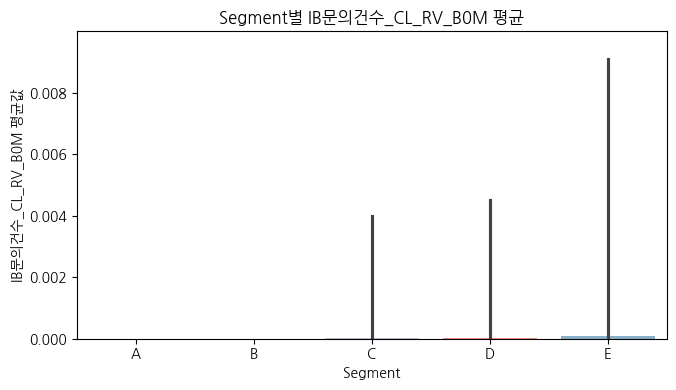

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


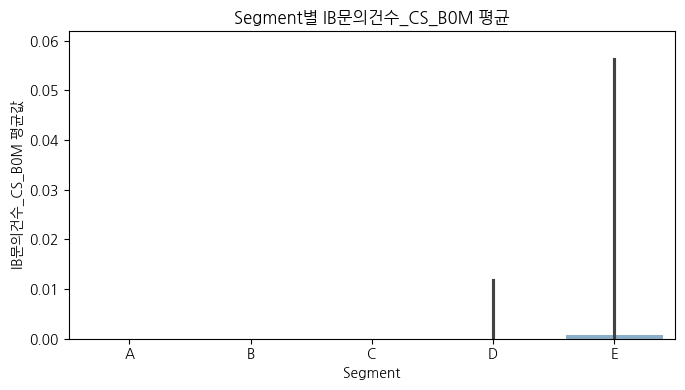

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


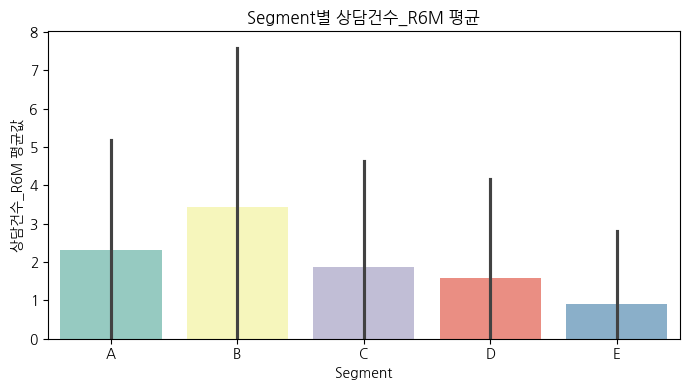

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


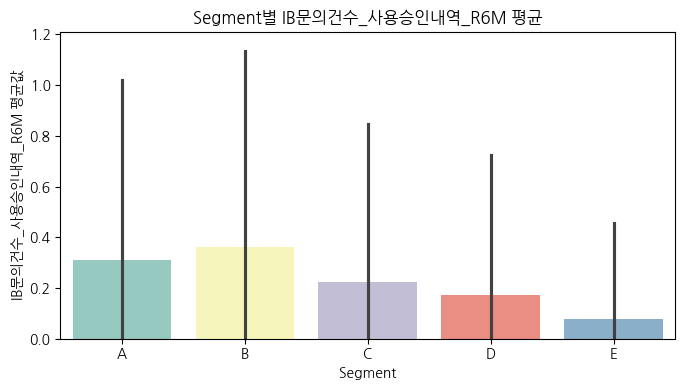

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


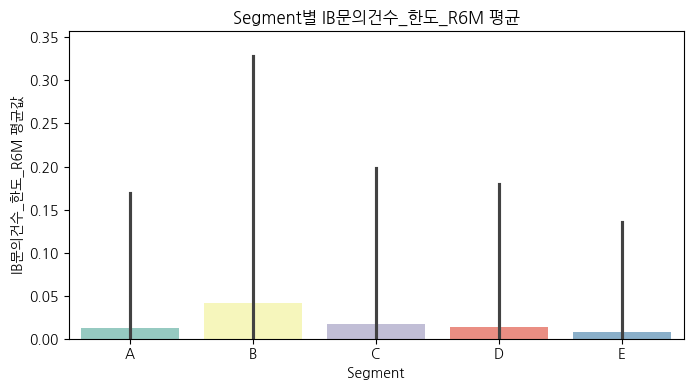

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


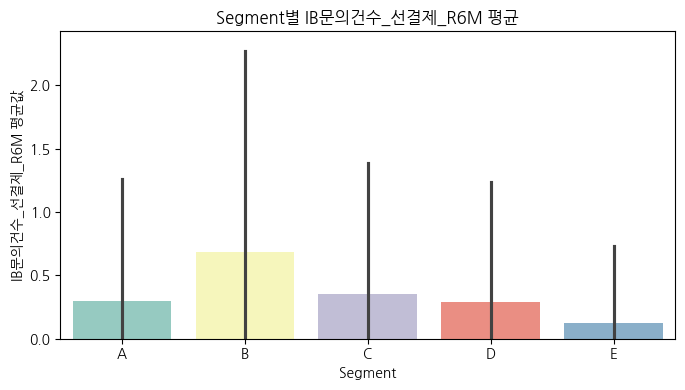

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


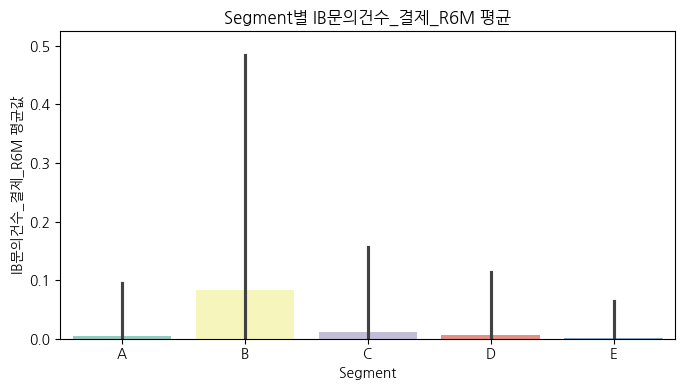

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


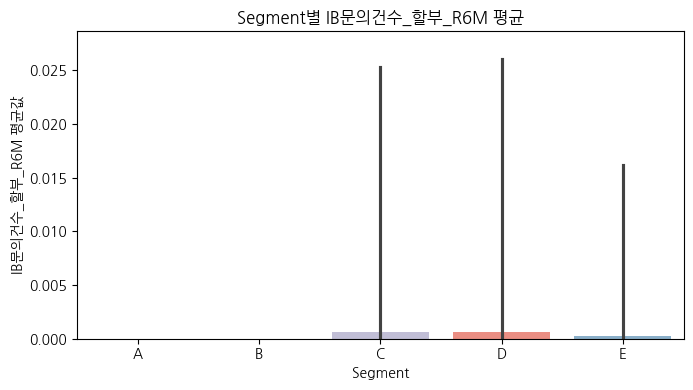

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


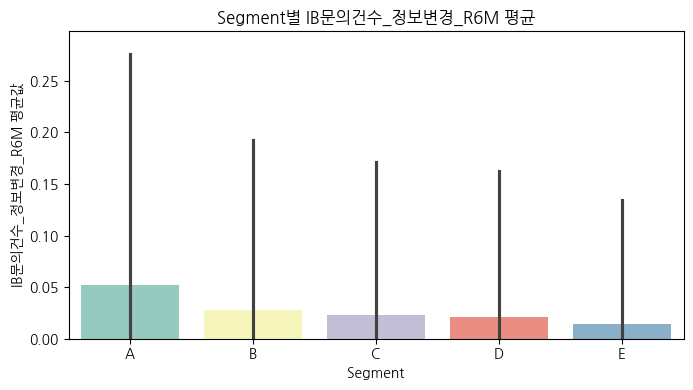

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


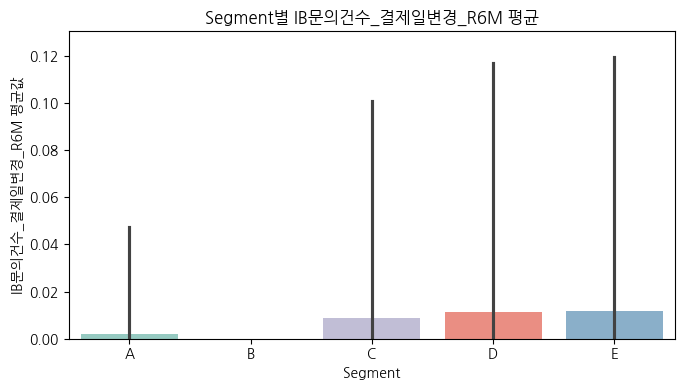

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


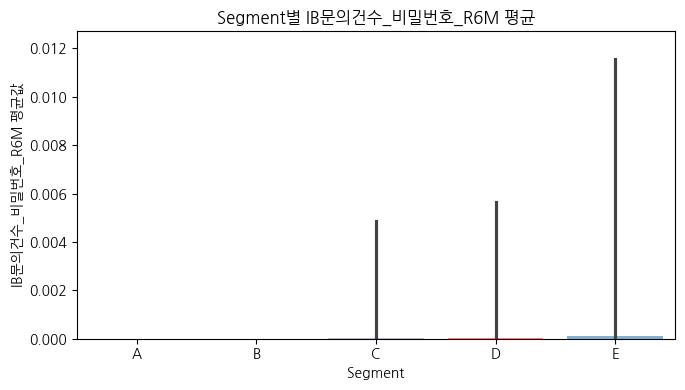

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


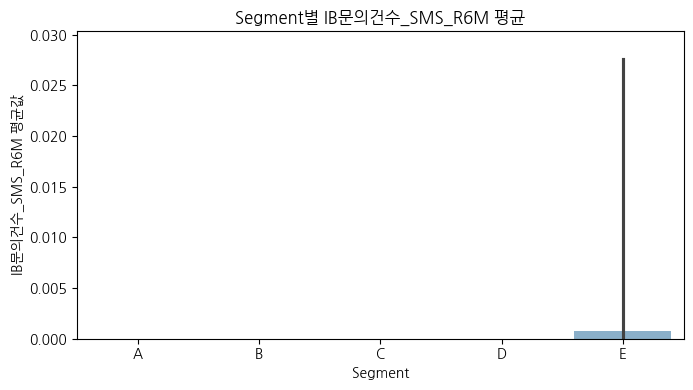

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


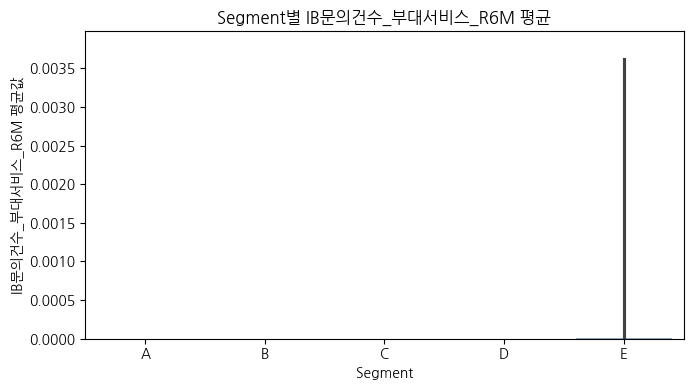

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


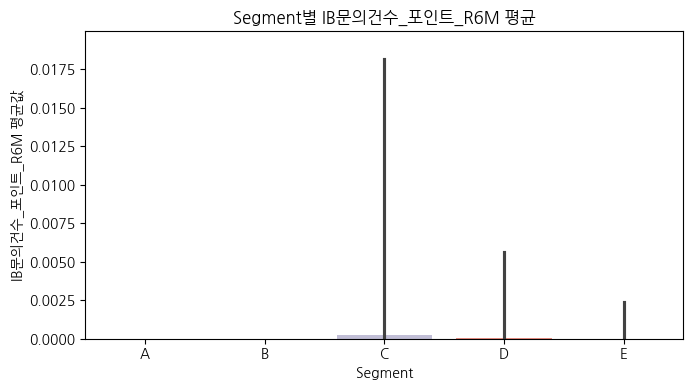

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


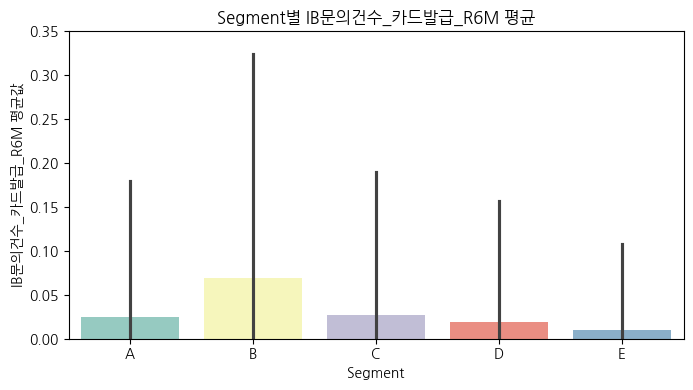

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


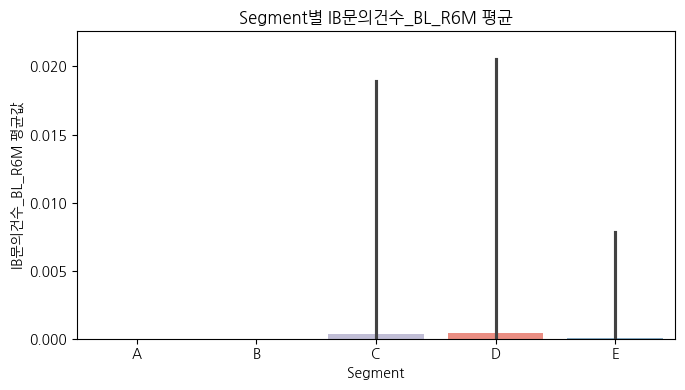

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


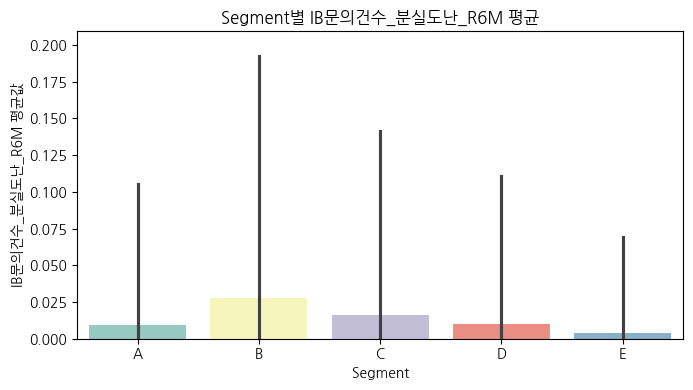

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


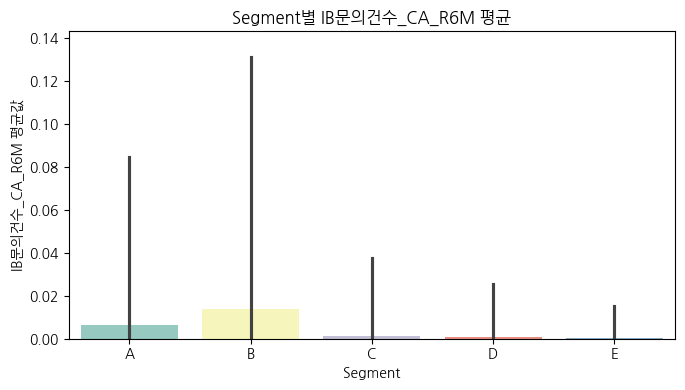

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


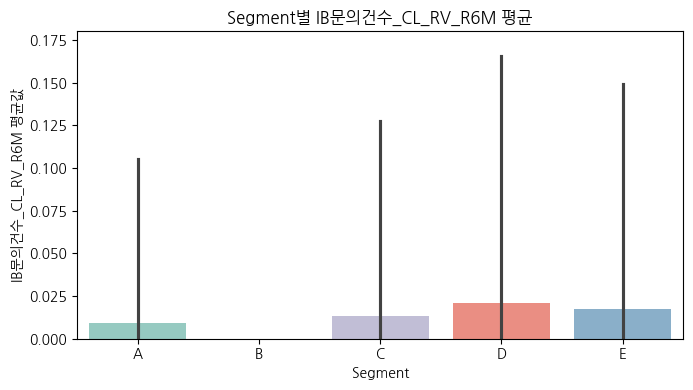

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


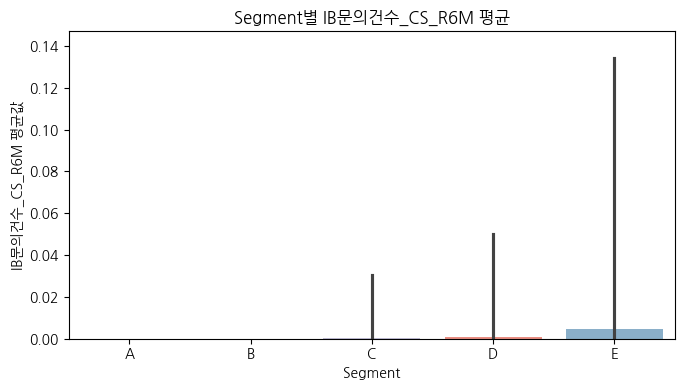

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


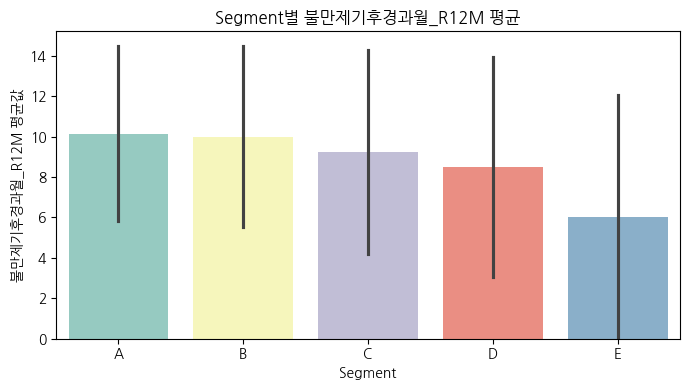

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


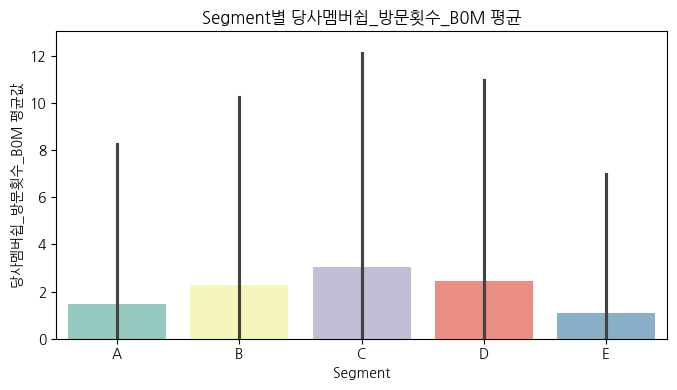

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


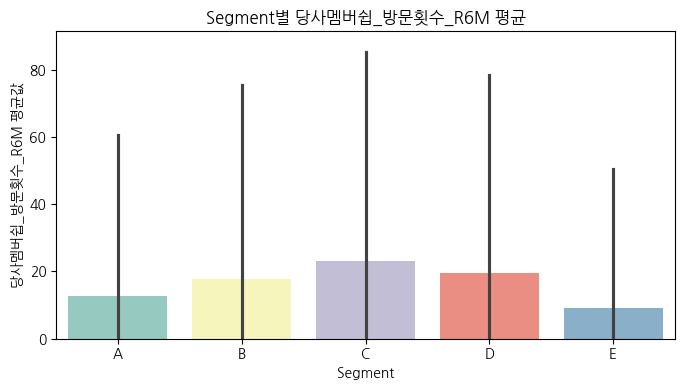

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


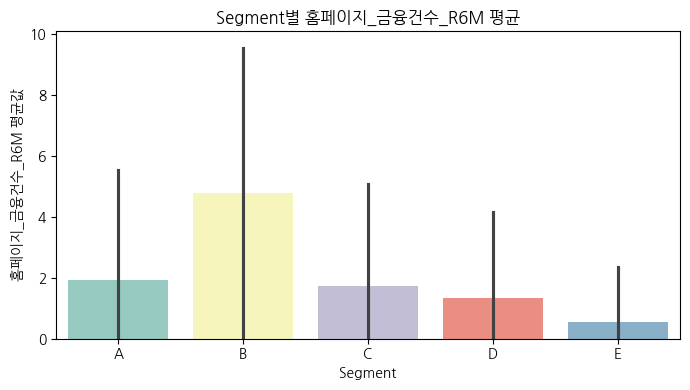

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


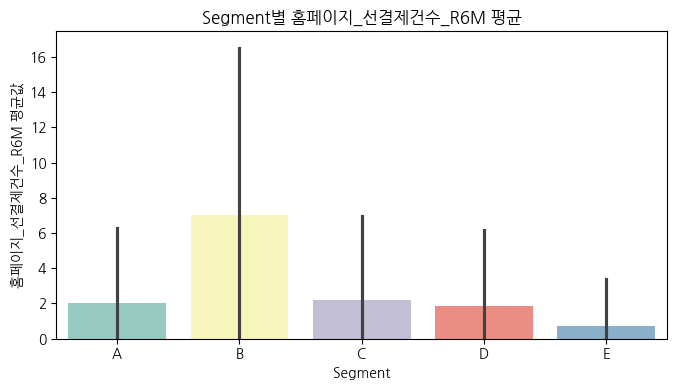

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


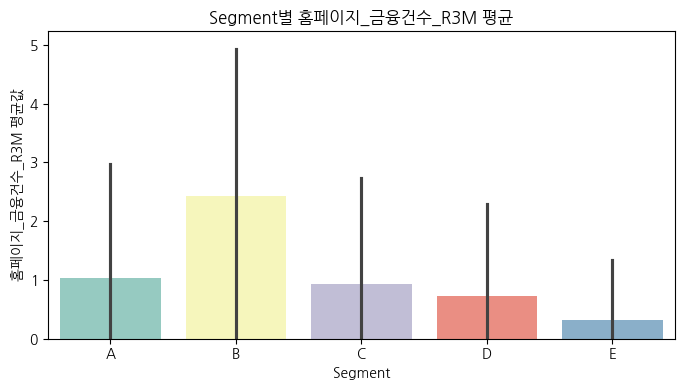

/tmp/ipython-input-9-3445222876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


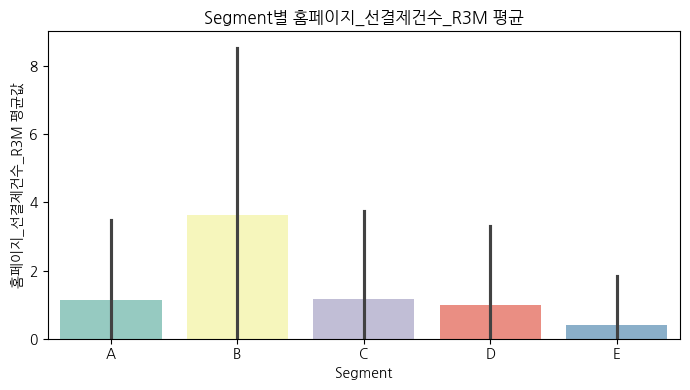

In [9]:
# 바 플롯을 그리고 싶은 칼럼 리스트
cols = [
    '인입후경과월_ARS', '인입횟수_ARS_B0M', '이용메뉴건수_ARS_B0M', '방문후경과월_PC_R6M',
    '방문후경과월_앱_R6M', '방문횟수_모바일웹_R6M', '방문후경과월_모바일웹_R6M', '방문횟수_PC_B0M',
    '방문횟수_앱_B0M', '방문횟수_모바일웹_B0M', '인입횟수_IB_R6M', '이용메뉴건수_IB_R6M',
    '인입후경과월_IB_R6M', '인입횟수_IB_B0M', '이용메뉴건수_IB_B0M', '인입불만후경과월_IB_R6M',
    '상담건수_B0M', 'IB문의건수_사용승인내역_B0M', 'IB문의건수_선결제_B0M', 'IB문의건수_카드발급_B0M',
    'IB문의건수_CL_RV_B0M', 'IB문의건수_CS_B0M', '상담건수_R6M', 'IB문의건수_사용승인내역_R6M',
    'IB문의건수_한도_R6M', 'IB문의건수_선결제_R6M', 'IB문의건수_결제_R6M', 'IB문의건수_할부_R6M',
    'IB문의건수_정보변경_R6M', 'IB문의건수_결제일변경_R6M', 'IB문의건수_비밀번호_R6M',
    'IB문의건수_SMS_R6M', 'IB문의건수_부대서비스_R6M', 'IB문의건수_포인트_R6M',
    'IB문의건수_카드발급_R6M', 'IB문의건수_BL_R6M', 'IB문의건수_분실도난_R6M',
    'IB문의건수_CA_R6M', 'IB문의건수_CL_RV_R6M', 'IB문의건수_CS_R6M', '불만제기후경과월_R12M',
    '당사멤버쉽_방문횟수_B0M', '당사멤버쉽_방문횟수_R6M', '홈페이지_금융건수_R6M',
    '홈페이지_선결제건수_R6M', '홈페이지_금융건수_R3M', '홈페이지_선결제건수_R3M'
]

# 세그먼트 순서 지정
segment_order = ['A', 'B', 'C', 'D', 'E']

# 바 플롯 반복 생성
for col in cols:
    plt.figure(figsize=(7, 4))
    sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)
    plt.title(f'Segment별 {col} 평균')
    plt.xlabel('Segment')
    plt.ylabel(f'{col} 평균값')
    plt.tight_layout()
    plt.ylim(bottom=0)
    plt.show()

세그먼트가 E에 대한 평균값이 작거나 큰 특성을 가진 칼럼들의 중에서 평균값으로 부터의 분산이 작은 것을 선택하기 위해 도수분포를 그려봤지만 판단하기가 어려워서 카아제곱 검정의 값이 0.05 미만인 것을 선택.

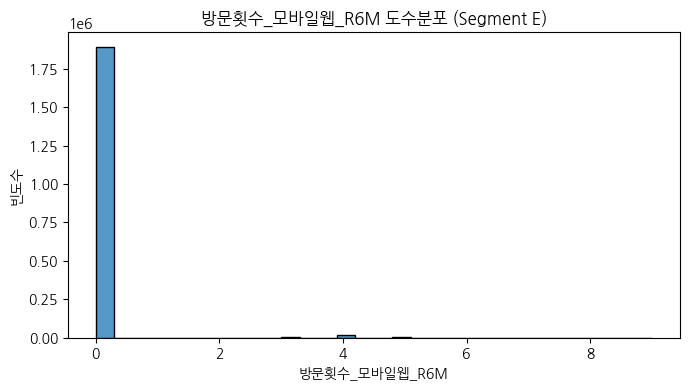

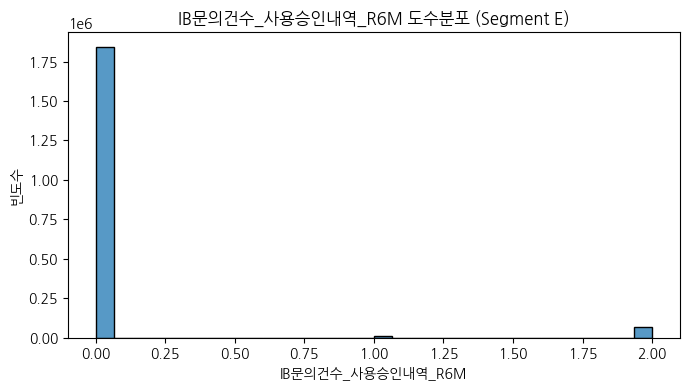

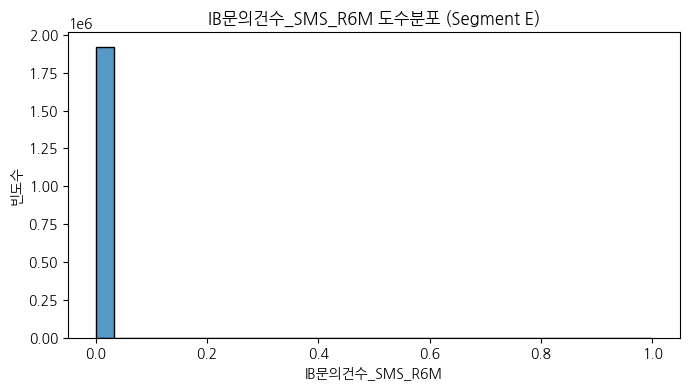

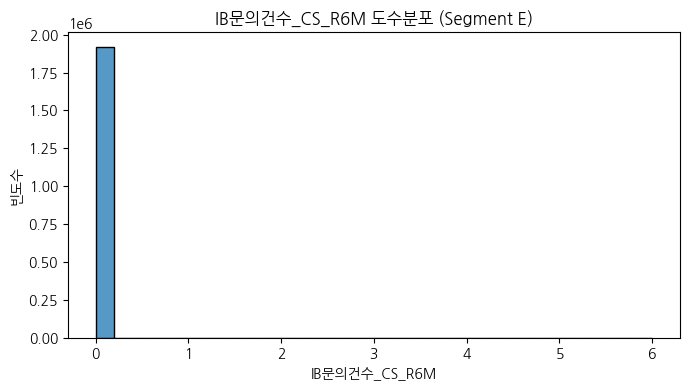

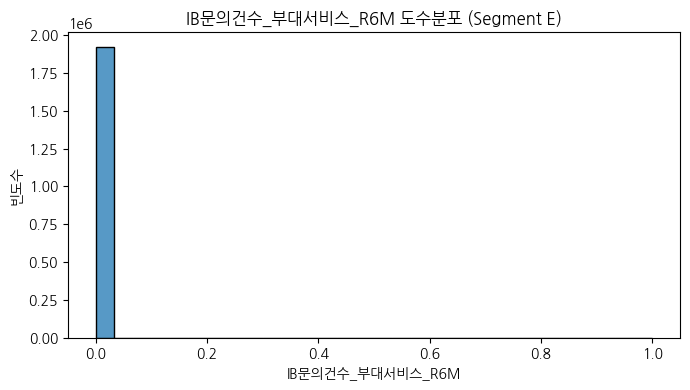

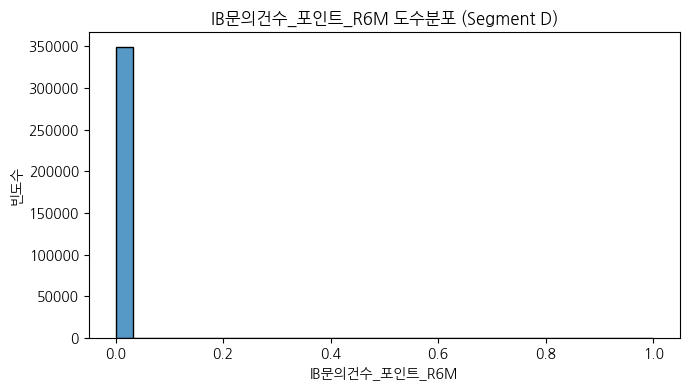

In [ ]:
# 1. Segment가 'E'인 경우에 대한 칼럼들
cols_E = [
    '방문횟수_모바일웹_R6M',
    'IB문의건수_사용승인내역_R6M',
    'IB문의건수_SMS_R6M',
    'IB문의건수_CS_R6M',
    'IB문의건수_부대서비스_R6M'
]

# 2. Segment가 'D'인 경우에 대한 칼럼
cols_D = ['IB문의건수_포인트_R6M']

# Segment E - 도수분포
for col in cols_E:
    subset = df_all[df_all['Segment'] == 'E']
    plt.figure(figsize=(7, 4))
    sns.histplot(subset[col], bins=30, kde=False)
    plt.title(f'{col} 도수분포 (Segment E)')
    plt.xlabel(col)
    plt.ylabel('빈도수')
    plt.tight_layout()
    plt.show()

# Segment D - 도수분포
for col in cols_D:
    subset = df_all[df_all['Segment'] == 'D']
    plt.figure(figsize=(7, 4))
    sns.histplot(subset[col], bins=30, kde=False)
    plt.title(f'{col} 도수분포 (Segment D)')
    plt.xlabel(col)
    plt.ylabel('빈도수')
    plt.tight_layout()
    plt.show()

In [13]:
from sklearn.preprocessing import KBinsDiscretizer
from scipy.stats import chi2_contingency
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

# Segment A~E만 선택
cde_df = df_all[df_all['Segment'].isin(['A','B','C','D','E'])].copy()

# 수치형 컬럼 자동 추출 (ID 제외)
numeric_cols = cde_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['ID']]

results = []

for col in numeric_cols:
    try:
        # 5분위로 binning (quantile 기반)
        discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
        cde_df['binned'] = discretizer.fit_transform(cde_df[[col]])

        # 교차표 생성
        contingency = pd.crosstab(cde_df['binned'], cde_df['Segment'])

        # 카이제곱 검정
        chi2, p, dof, expected = chi2_contingency(contingency)

        results.append({
            'Feature': col,
            'Chi2 Stat': chi2,
            'p-value': round(p, 10),
        })
    except Exception:
        continue  # 에러나는 컬럼은 건너뜀

# 전체 결과를 p-value 기준으로 내림차순 정렬
result_df = pd.DataFrame(results)
result_df_sorted = result_df.sort_values(by='p-value', ascending=False)
# p-value < 0.05인 결과만 필터링
significant_df = result_df_sorted[result_df_sorted['p-value'] < 0.05]

# 출력
display(significant_df[['Feature', 'Chi2 Stat', 'p-value']])

,Feature,Chi2 Stat,p-value
27,인입후경과월_IB_R6M,27265.521030,0.0
26,이용메뉴건수_IB_R6M,41355.126665,0.0
24,인입일수_IB_R6M,41470.711548,0.0
11,방문후경과월_앱_R6M,62167.492098,0.0
9,방문일수_앱_R6M,67545.562614,0.0
3,인입후경과월_ARS,16810.032370,0.0
1,인입일수_ARS_R6M,45099.523314,0.0
25,인입월수_IB_R6M,41327.437986,0.0
22,인입횟수_IB_R6M,41455.004761,0.0
2,인입월수_ARS_R6M,44369.040988,0.0


ppt 작성을 위한 시각화

/tmp/ipython-input-6-1216760135.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


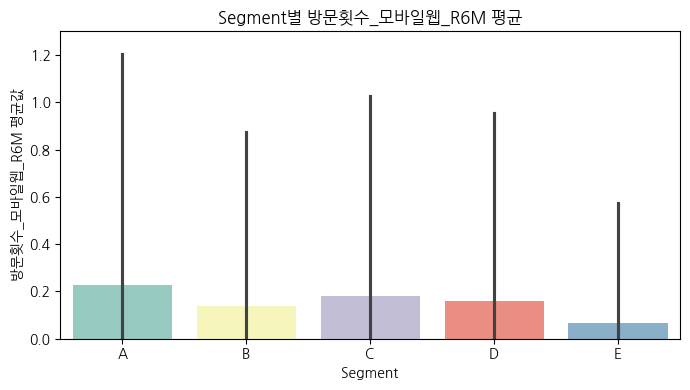

/tmp/ipython-input-6-1216760135.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


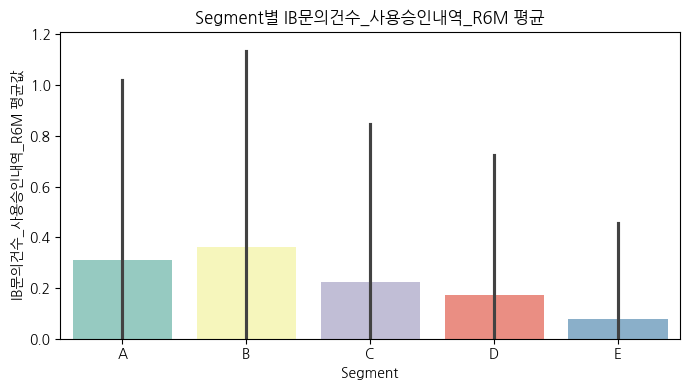

/tmp/ipython-input-6-1216760135.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


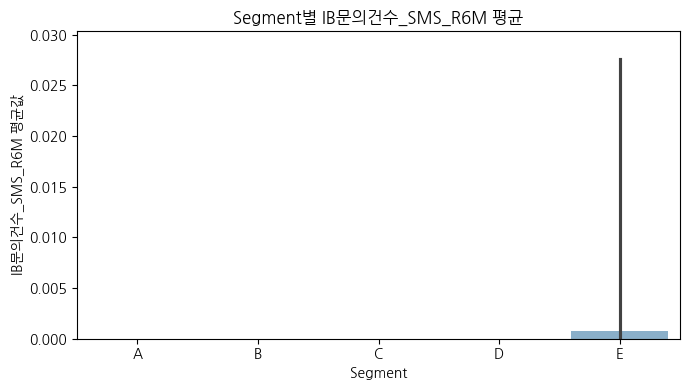

/tmp/ipython-input-6-1216760135.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


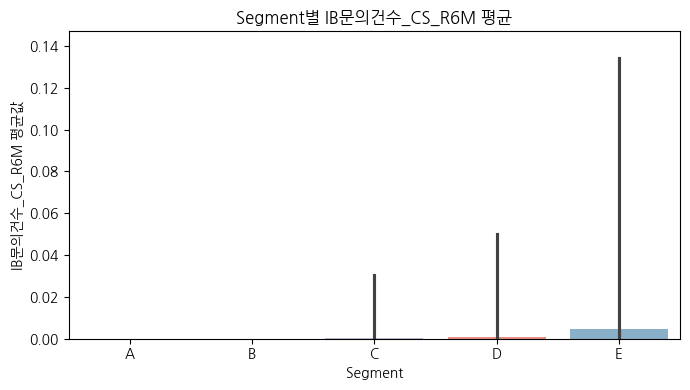

/tmp/ipython-input-6-1216760135.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


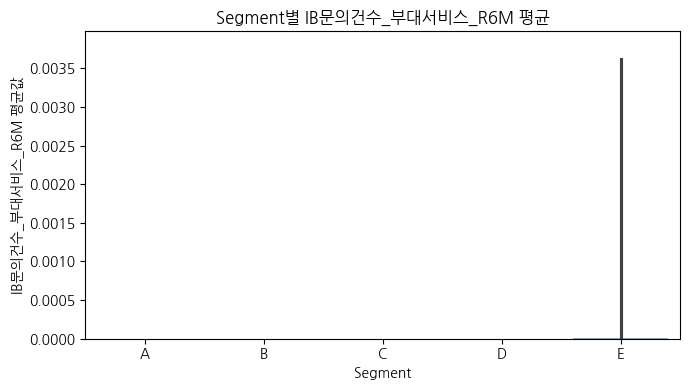

/tmp/ipython-input-6-1216760135.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)


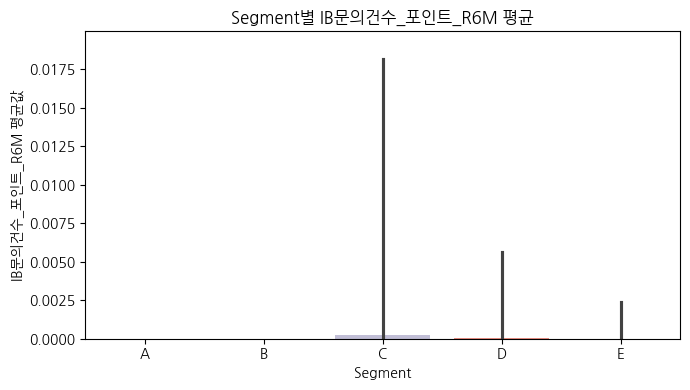

In [6]:
# 바 플롯을 그리고 싶은 칼럼 리스트
cols = [
   '방문횟수_모바일웹_R6M', 'IB문의건수_사용승인내역_R6M', 'IB문의건수_SMS_R6M',
    'IB문의건수_CS_R6M', 'IB문의건수_부대서비스_R6M','IB문의건수_포인트_R6M'
]

# 세그먼트 순서 지정
segment_order = ['A', 'B', 'C', 'D', 'E']

for col in cols:
    plt.figure(figsize=(7, 4))
    sns.barplot(data=df_all, x='Segment', y=col, errorbar='sd', palette='Set3', order=segment_order)
    plt.title(f'Segment별 {col} 평균')
    plt.xlabel('Segment')
    plt.ylabel(f'{col} 평균값')
    plt.ylim(bottom=0)  # ✅ Y축 하한을 0으로 고정
    plt.tight_layout()
    plt.show()